# PRE-INGESTION EXPLORATORY EDA — Local legacy 한국어–영어 번역 병렬 XLSX family

> **Notebook status:** `SUPPORTING / EXPLORATORY / PRE-INGESTION EDA / NOT G1 PASS`

| Traceability field | Value |
|---|---|
| Dataset local ID | `LOCAL_KO_EN_PARALLEL_XLSX_V1` |
| Inspected raw path | `/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/한국어-영어 번역(병렬) 말뭉치` |
| File-family mapping | 10 XLSX workbooks grouped as 구어체·대화체·뉴스·한국문화·조례·지자체웹; official AIHub ID UNKNOWN |
| File hashes / source manifest | 이 notebook 실행 시 모든 physical file SHA-256과 `RAW_FILE_MANIFEST_SHA`를 계산해 아래 inventory 및 output CSV/JSON에 기록 |
| Audit timestamp | 실행 cell에서 local timezone ISO-8601로 기록 |
| Population scope | SHA-256 고유 JSON/XLSX content의 **FULL POPULATION aggregate** |
| Visualization sample | `BLAKE2b(seed=20260816) mod 1000 < 10`, 약 1%; scatter/sample preview에만 사용 |
| Raw mutation | 없음; `data/raw/**` read-only |

이 notebook은 raw 구조와 관측 분포를 시각적으로 이해하기 위한 supporting artifact다. pair validity, primary corpus 적합성, Tokenization Premium, 또는 QC acceptance를 판단하지 않는다.


## 1. 실행 환경과 snapshot contract

질문: **어떤 raw file에서 어떤 범위로 계산했는가?**

아래 cell은 worktree root를 자동 탐색하고 공용 streaming helper를 불러온다. 외부 다운로드는 없다.


In [1]:
from pathlib import Path
import json, sys
from IPython.display import Markdown, display

def find_worktree_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'outputs/eda_raw/support/raw_eda_framework.py').exists():
            return candidate
    raise FileNotFoundError('worktree root not found')

WORKTREE_ROOT = find_worktree_root(Path.cwd().resolve())
sys.path.insert(0, str(WORKTREE_ROOT / 'outputs/eda_raw/support'))
from raw_eda_framework import (
    profile_dataset, save_artifacts, plot_overview, plot_lengths,
    plot_categories, plot_quality,
)

CONFIG = {'dataset_local_id': 'LOCAL_KO_EN_PARALLEL_XLSX_V1', 'dataset_title': 'Local legacy 한국어–영어 번역 병렬 XLSX family', 'short_name': 'legacy_ko_en_parallel_xlsx', 'artifact_prefix': 'legacy_ko_en_xlsx', 'raw_dir': '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/한국어-영어 번역(병렬) 말뭉치', 'mapping': '10 XLSX workbooks grouped as 구어체·대화체·뉴스·한국문화·조례·지자체웹; official AIHub ID UNKNOWN', 'category_plot_dimensions': ['대분류', '언론사', '자동분류1', '지자체']}
OUTPUT_DIR = WORKTREE_ROOT / 'outputs/eda_raw' / CONFIG['artifact_prefix']
FIGURE_DIR = WORKTREE_ROOT / 'outputs/figures/eda_raw' / CONFIG['artifact_prefix']
print('WORKTREE_ROOT =', WORKTREE_ROOT)
print('Python =', sys.executable)
print('RAW =', CONFIG['raw_dir'])


WORKTREE_ROOT = /home/sieg/projects-wsl/Tokenization_Premium/.agent_worktrees/raw-eda
Python = /home/sieg/projects-wsl/Tokenization_Premium/.venv/bin/python
RAW = /home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/한국어-영어 번역(병렬) 말뭉치


## 2. Full-population streaming profile

질문: **전체 모집단의 규모·스키마·결측·길이·category·noise·중복 신호는 무엇인가?**

- JSON은 top-level `data[]`를 순차 파싱한다.
- XLSX는 `openpyxl(read_only=True)`로 행을 순차 처리한다.
- byte-identical source/label copies는 inventory에는 남기되 내용 집계는 SHA-256당 한 번만 한다.
- audit 중 size/mtime이 달라지면 결과 저장 전에 실행을 중단한다.


In [2]:
result = profile_dataset(CONFIG)
save_artifacts(result, OUTPUT_DIR)
display(Markdown('### Snapshot summary'))
display(result['summary'])
display(Markdown('### Physical file inventory and SHA-256'))
display(result['inventory'])


### Snapshot summary

{'dataset_local_id': 'LOCAL_KO_EN_PARALLEL_XLSX_V1',
 'dataset_title': 'Local legacy 한국어–영어 번역 병렬 XLSX family',
 'audit_timestamp': '2026-08-16T14:11:02+09:00',
 'audit_completed_timestamp': '2026-08-16T14:12:31+09:00',
 'raw_dir': '/home/sieg/projects-wsl/Tokenization_Premium/data/raw/aigub/한국어-영어 번역(병렬) 말뭉치',
 'physical_file_count': 10,
 'unique_content_file_count': 10,
 'profiled_unique_data_files': 10,
 'logical_record_count': 1602418,
 'sample_record_count': 15966,
 'population_scope': 'FULL POPULATION AGGREGATES over unique SHA-256 JSON/XLSX content',
 'sample_method': 'deterministic BLAKE2b(seed=20260816) hash threshold 10/1000 (~1%); scatter/sample only',
 'notebook_status': 'SUPPORTING / EXPLORATORY / PRE-INGESTION EDA / NOT G1 PASS',
 'raw_file_manifest_sha': 'd3b43a0e6cdfbfadc8d26f7dec0aa4721d13dc28c9c78de117628c865054aeb1',
 'stability_counts': {'STABLE_FILE': 10,
  'DOWNLOAD_IN_PROGRESS': 0,
  'PARTIAL_DOWNLOAD': 0,
  'UNKNOWN': 0}}

### Physical file inventory and SHA-256

,relative_path,bytes,mtime_epoch_ns,sha256,format,split,role,direction,duplicate_of,stability_state
0,1_구어체(1).xlsx,15816496,1786853967795620099,0fd712b2d62c054bed364fd41af59019a3cc6c05093d05...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
1,1_구어체(2).xlsx,14317360,1786853967689287058,f673f1c8fb73bad83e9ba097a45e47883f94d009d51ad4...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
2,2_대화체.xlsx,9566182,1786853967256621578,b98b105d8f5efd20d6a1a6a69071d8b13ddc337c817c17...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
3,3_문어체_뉴스(1)/3_문어체_뉴스(1)_200226.xlsx,51434832,1786853969423615634,a4de4cb3a40831cf673be39a35b64945e1ea0838eca143...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
4,3_문어체_뉴스(2).xlsx,42678691,1786853969012950094,b1ff2e1fb6c9b10a2d90e0b205963e79215858eff45657...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
5,3_문어체_뉴스(3).xlsx,54225893,1786853969570281899,1deaa6e2cbe1168083de2401c08e283ccf070118dc3842...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
6,3_문어체_뉴스(4).xlsx,46195584,1786853969177949643,56434ff93133e9349d1ed4a93ef557907c166fe5baf2b5...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
7,4_문어체_한국문화.xlsx,15981787,1786853967813953383,a0f5f64b99f644ce634661f8b8c478202adea50d6be147...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
8,5_문어체_조례.xlsx,15355237,1786853967766286846,063259a9c136d6206c828c22ab06d66f07afb8d9af7a74...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE
9,6_문어체_지자체웹사이트.xlsx,17457662,1786853967901953143,322da04a7912ca24d7e81b9a0906c739a43660e2532058...,XLSX,UNSPLIT,WORKBOOK,KO_FIELD_TO_EN_FIELD,,STABLE_FILE


## 3. 구조·규모·coverage

질문: **어떤 file group이 corpus 규모를 구성하고, core text/metadata coverage는 어떤가?**


,group,records
2,뉴스,801387
0,구어체,400000
3,한국문화,100646
4,조례,100298
5,지자체웹,100087
1,대화체,100000


,group,field,records,absent,null,empty,missing_or_empty_rate,type_counts
11,뉴스,자동분류3,801387,0,542,453201,0.566197,"{""null"": 542, ""string"": 800845}"
10,뉴스,자동분류2,801387,0,325,254341,0.317782,"{""null"": 325, ""string"": 801062}"
4,뉴스,URL,801387,0,0,95180,0.118769,"{""string"": 801387}"
0,구어체,SID,400000,0,0,0,0.000000,"{""integer"": 200000, ""number"": 200000}"
1,구어체,번역문,400000,0,0,0,0.000000,"{""string"": 400000}"
2,구어체,원문,400000,0,0,0,0.000000,"{""string"": 400000}"
3,뉴스,ID,801387,0,0,0,0.000000,"{""integer"": 801387}"
5,뉴스,날짜,801387,0,0,0,0.000000,"{""datetime"": 296665, ""integer"": 504722}"
6,뉴스,번역문,801387,0,0,0,0.000000,"{""string"": 801387}"
7,뉴스,언론사,801387,0,0,0,0.000000,"{""string"": 801387}"


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 600.


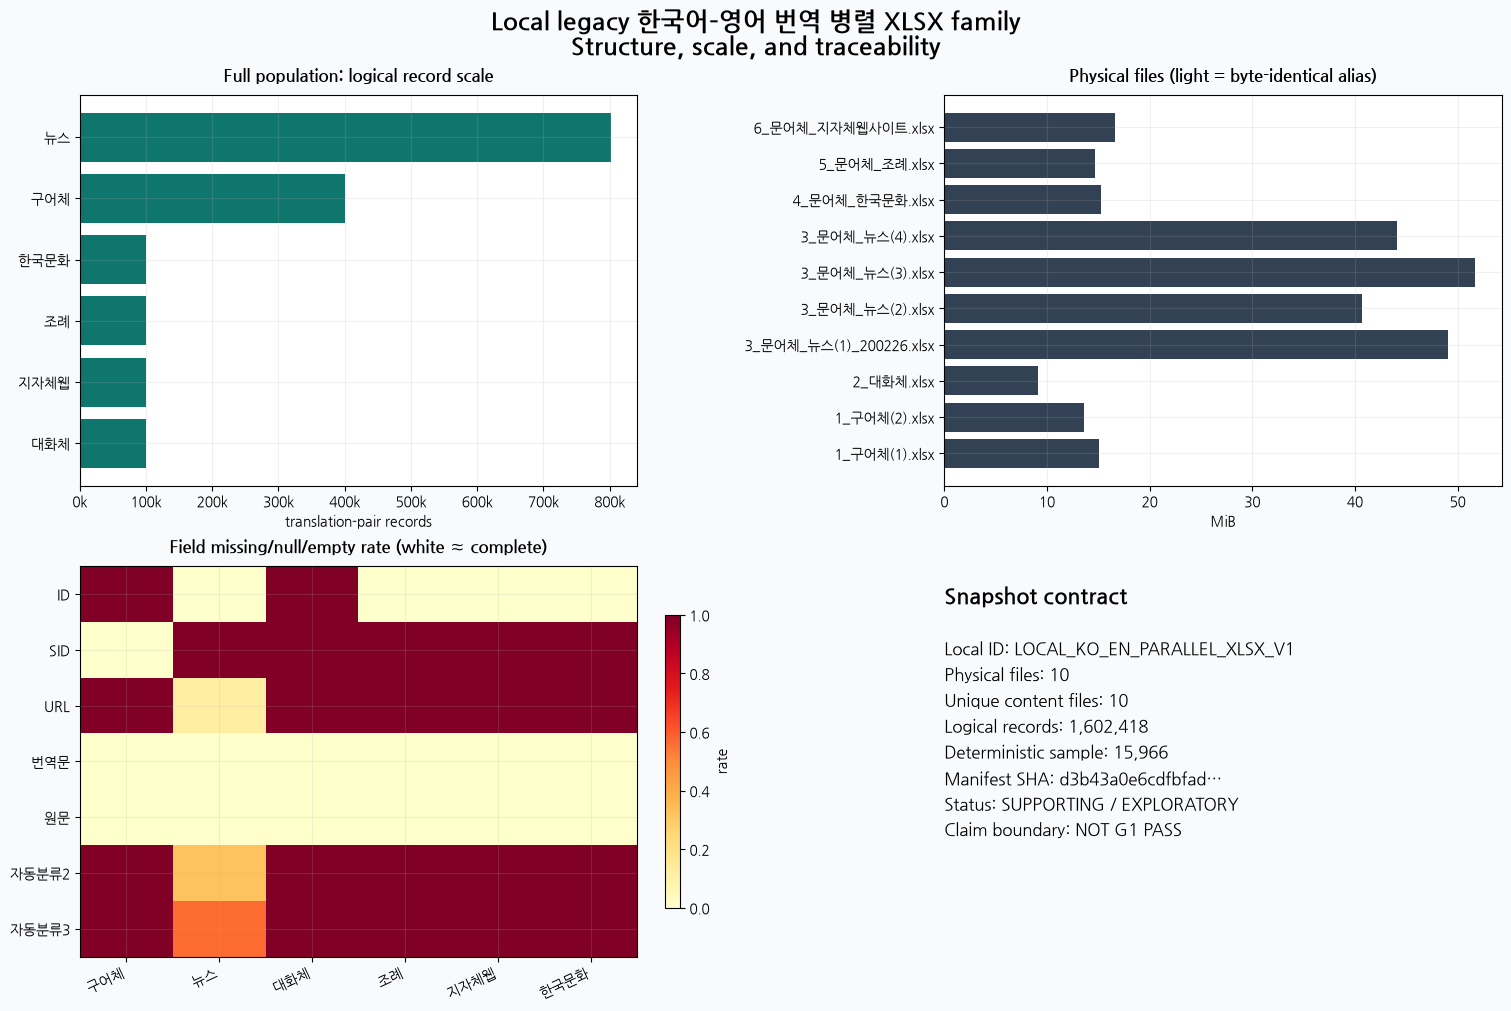

In [3]:
display(result['record_counts'].sort_values('records', ascending=False))
display(result['schema'].sort_values(['missing_or_empty_rate', 'group', 'field'], ascending=[False, True, True]).head(30))
plot_overview(result, FIGURE_DIR)


## 4. KO/EN raw length structure

질문: **raw codepoint/UTF-8 byte 길이의 중심·꼬리와 KO–EN 관계가 group별로 어떻게 다른가?**

위쪽 분포선과 p50/p95는 full population이다. hexbin만 deterministic 약 1% sample이다.


,group,language,metric,count,min,p50,p90,p95,p99,max,mean
0,구어체,EN,codepoints,400000,10,51,95,111,143,312,57.613825
2,구어체,KO,codepoints,400000,4,26,45,52,64,117,29.081320
4,뉴스,EN,codepoints,801387,20,174,258,286,343,706,173.244872
6,뉴스,KO,codepoints,801387,15,71,97,105,120,220,69.154871
8,대화체,EN,codepoints,100000,10,63,92,102,125,332,65.610120
10,대화체,KO,codepoints,100000,5,29,40,44,53,162,30.693080
12,조례,EN,codepoints,100298,39,210,338,380,466,999,222.892431
14,조례,KO,codepoints,100298,14,70,110,121,142,359,74.305549
16,지자체웹,EN,codepoints,100087,26,195,306,339,402,704,201.752305
18,지자체웹,KO,codepoints,100087,22,75,113,122,136,186,76.811494


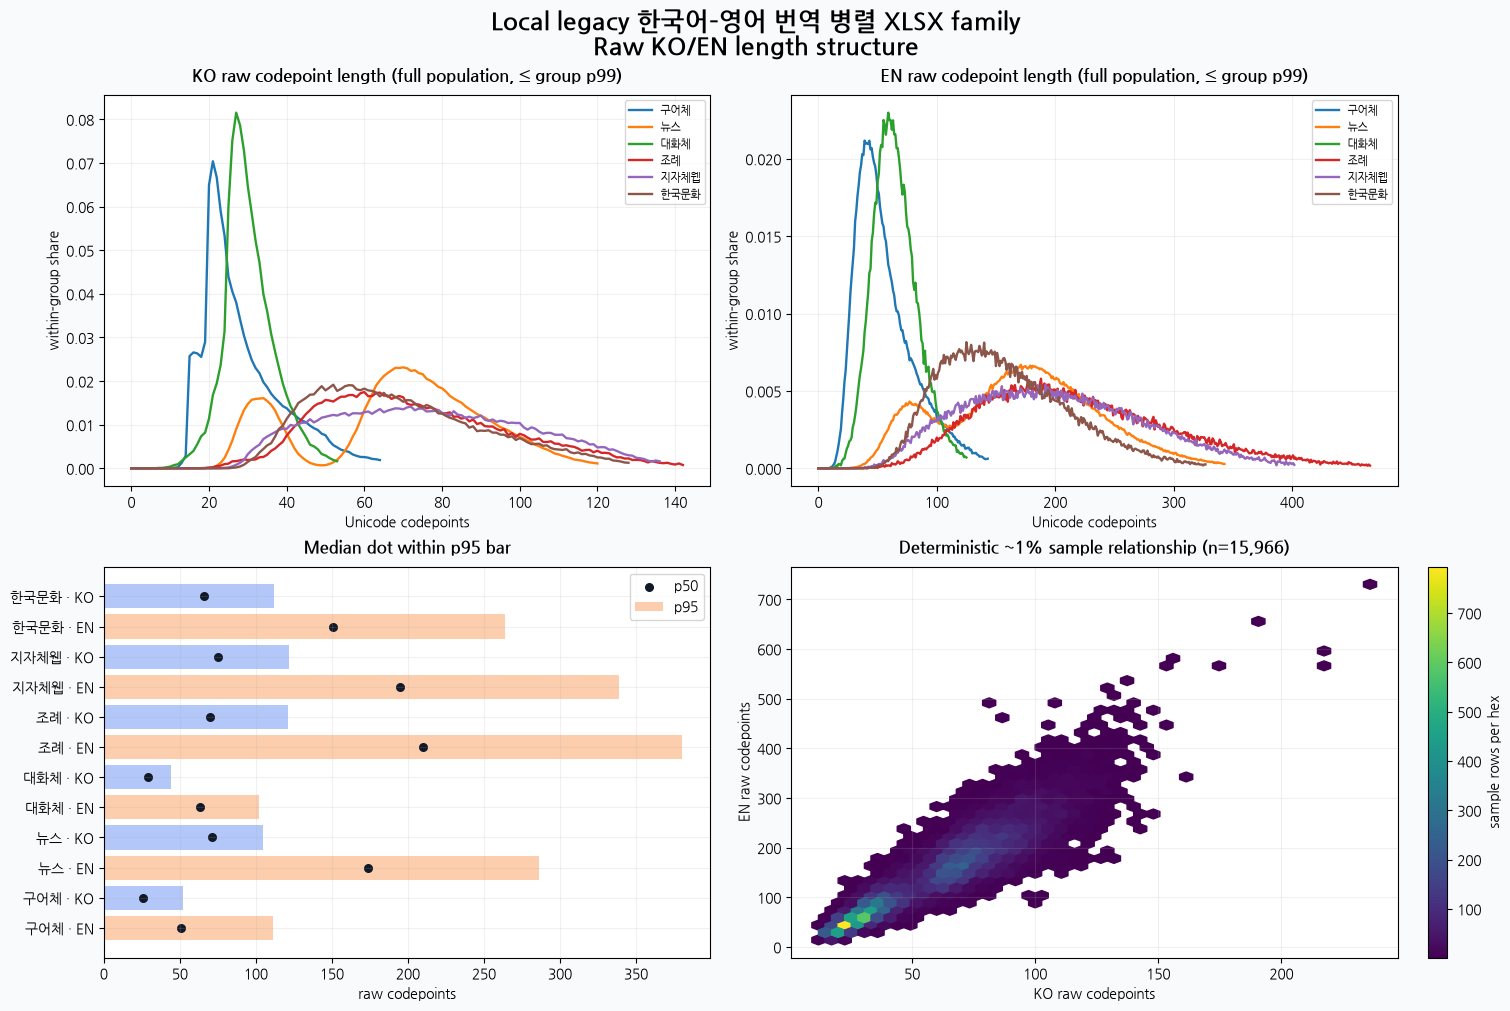

In [4]:
display(result['length_summary'].sort_values(['metric', 'group', 'language']))
plot_lengths(result, FIGURE_DIR)


## 5. Domain/source/category composition

질문: **어떤 source/domain/category가 실제 row volume을 구성하는가?**

범주 수가 큰 field는 top raw value만 시각화하며, 전체 count table은 CSV artifact로 남긴다.


,dimension,value,count
2,대분류,여행/쇼핑,46524
0,대분류,비즈니스,28064
4,대분류,일상대화,24012
1,대분류,스포츠,1000
3,대분류,의학,400
...,...,...,...
3187,키워드,문화·교육,2165
3215,키워드,생활·민속,1686
3267,키워드,정치·경제·사회,619
3242,키워드,역사/근현대|성씨·인물/근현대 인물,561


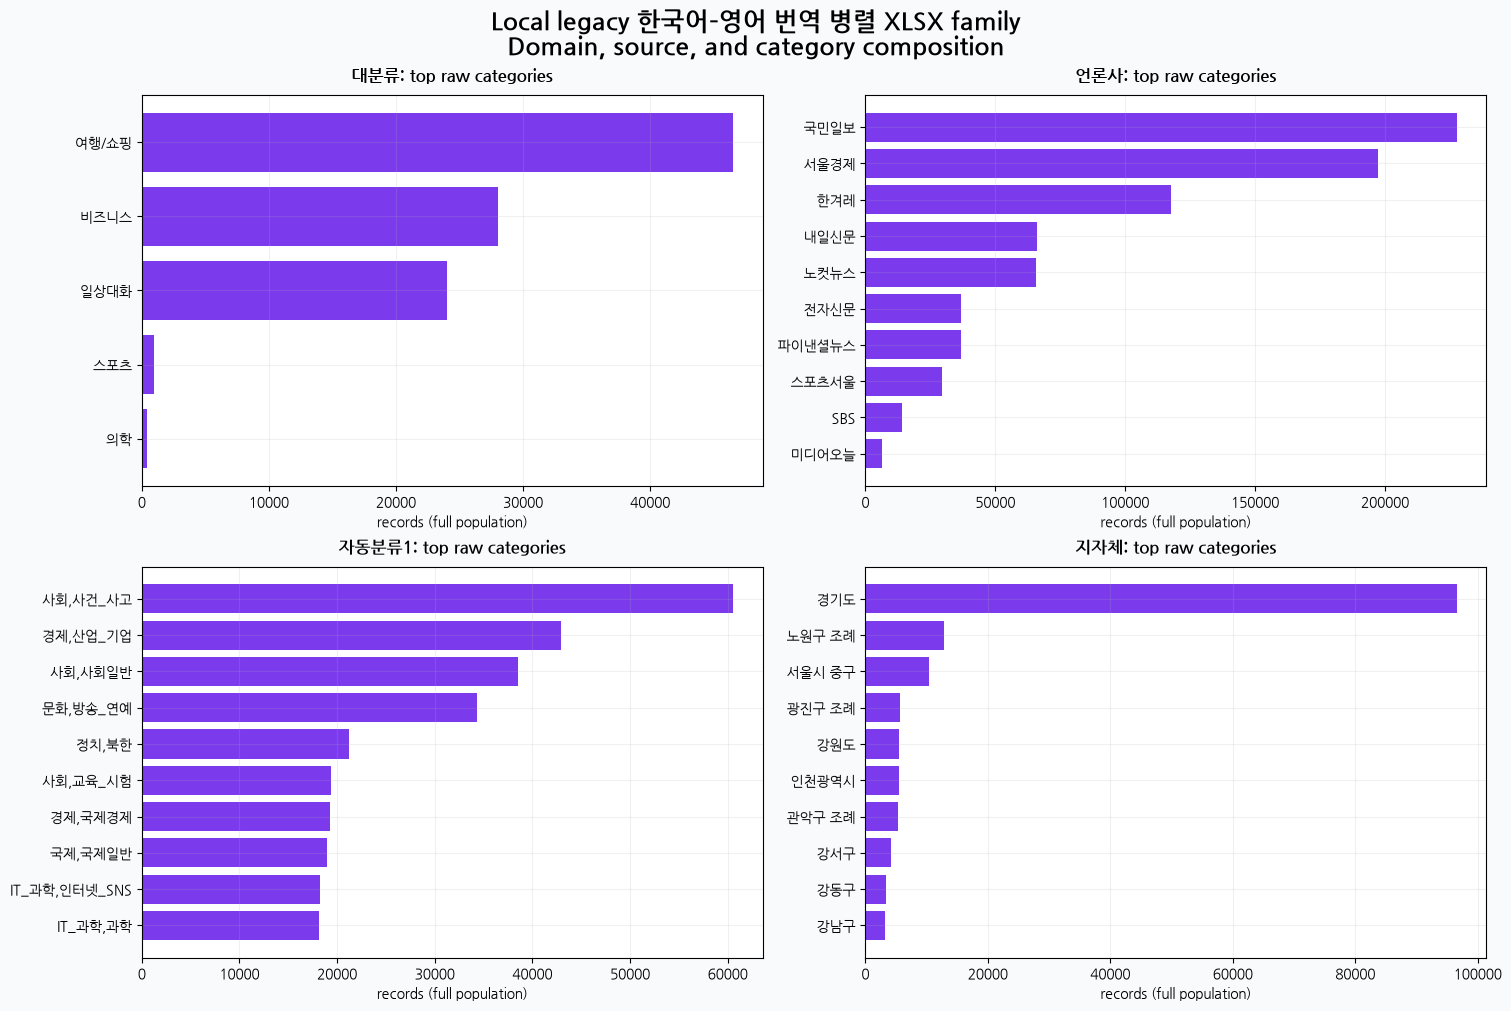

In [5]:
top_categories = (result['categories'].groupby(['dimension', 'value'], as_index=False)['count'].sum()
                  .sort_values(['dimension', 'count'], ascending=[True, False])
                  .groupby('dimension').head(10))
display(top_categories)
plot_categories(result, FIGURE_DIR)


## 6. Potential QC signals — acceptance가 아님

질문: **missing metadata, whitespace/script/markup 신호, raw duplicate 후보는 어디에 집중되는가?**

모든 항목은 `OBSERVED RAW DISTRIBUTION` 또는 `POTENTIAL QC ISSUE`다. 자동 오류 판정이나 정규화 근거가 아니다.


,scope,duplicate_pair_rows_after_first,distinct_duplicate_pair_hashes,validation_rows_overlapping_training_pair,candidate_method
0,dataset,2494,2494,0,BLAKE2b-64 raw KO+EN; collision possible; no n...


,group,language,metric,row_count,records,rows_per_100k
28,한국문화,KO,cross_script,14779,100646,14684.140453
10,뉴스,KO,cross_script,103313,801387,12891.773887
22,지자체웹,KO,cross_script,9771,100087,9762.506619
2,구어체,KO,cross_script,18870,400000,4717.500000
15,대화체,KO,cross_script,1317,100000,1317.000000
18,조례,KO,cross_script,576,100298,574.288620
30,한국문화,KO,html_like,122,100646,121.216939
25,한국문화,EN,html_like,114,100646,113.268287
7,뉴스,EN,html_like,410,801387,51.161299
20,지자체웹,EN,html_like,38,100087,37.966969


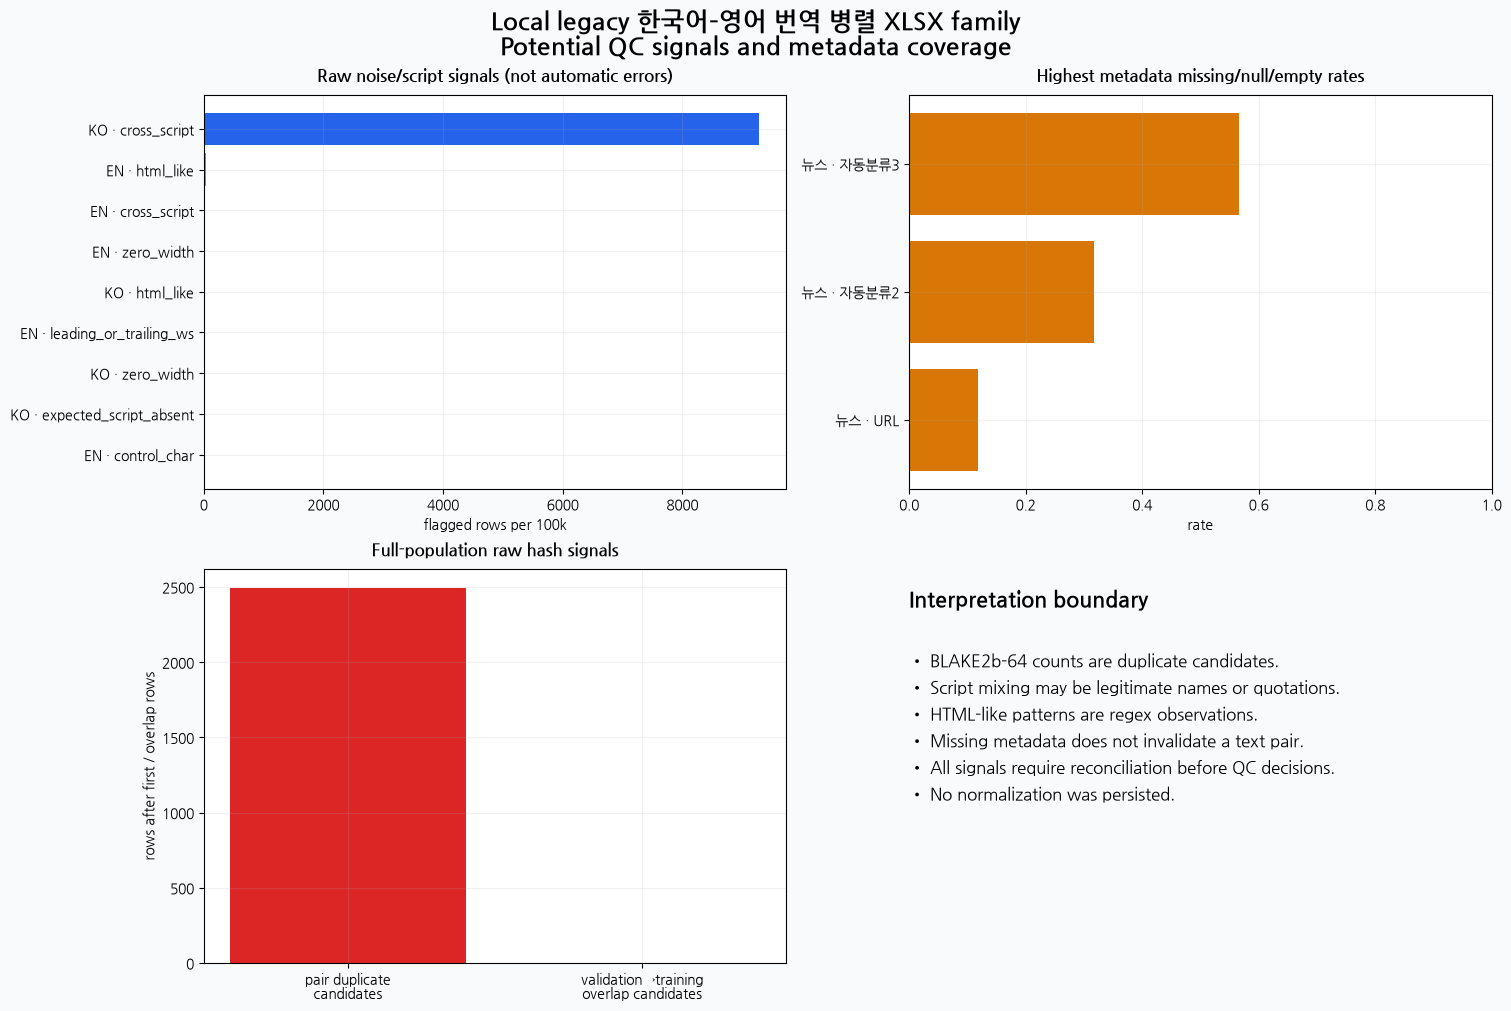

In [6]:
display(result['duplicates'])
display(result['noise'].sort_values('rows_per_100k', ascending=False).head(30))
plot_quality(result, FIGURE_DIR)


## 7. Deterministic sample structure

질문: **집계표 뒤의 실제 row 구조가 어떤 모습인가?**

아래 preview는 scatter와 동일한 deterministic hash sample 중 일부다. `ko_preview`/`en_preview`는 표시 길이를 160 codepoint로 제한하며 원문을 수정하지 않는다.


In [7]:
sample_columns = [c for c in ['group','relative_path','row_number','pair_key','ko_preview','en_preview','ko_codepoints','en_codepoints','domain','subdomain','source','대분류','소분류','상황','언론사','키워드','지자체'] if c in result['samples'].columns]
display(result['samples'][sample_columns].head(12))
print(f"sample rows = {len(result['samples']):,}; full logical records = {result['summary']['logical_record_count']:,}")


,group,relative_path,row_number,pair_key,ko_preview,en_preview,ko_codepoints,en_codepoints,대분류,소분류,상황,언론사,키워드,지자체
0,구어체,1_구어체(1).xlsx,249,248,OSD 메뉴 SYSTEM 쪽을 보면 아웃풋 을 변경할 수 있다.,You can change the output if you look at the S...,35,73,NaN,NaN,NaN,NaN,NaN,NaN
1,구어체,1_구어체(1).xlsx,264,263,SpaceX가 수직이착륙 로켓을 개발하여 여러 비행시험을 시행한 사례가 있습니다.,SpaceX has developed a VTOL rocket and did a t...,45,57,NaN,NaN,NaN,NaN,NaN,NaN
2,구어체,1_구어체(1).xlsx,332,331,갤럭시 호텔에서 당신 집까지 얼마나 걸리나요?,How long does it take from the Galaxy hotel to...,25,57,NaN,NaN,NaN,NaN,NaN,NaN
3,구어체,1_구어체(1).xlsx,522,521,"동원아, 네가 요즘 너의 삶에 목표가 없는 것 때문에 많이 고민하는 것 같아서 내가...","Dong-won, I am writing you a letter because yo...",56,116,NaN,NaN,NaN,NaN,NaN,NaN
4,구어체,1_구어체(1).xlsx,571,570,롯데칠성음료가 제조 및 판매하는 한국 맥주입니다.,It is Korean beer that Lotte-Chilsung Beverage...,27,76,NaN,NaN,NaN,NaN,NaN,NaN
5,구어체,1_구어체(1).xlsx,979,978,엑스맨 영화로 많은 인기를 얻었습니다.,He gained great popularity thanks to the movie...,21,53,NaN,NaN,NaN,NaN,NaN,NaN
6,구어체,1_구어체(1).xlsx,1163,1162,제니퍼가 페이스북에 내 사진을 계속 올리는 이유가 뭐야?,Why is Jenifer uploading my photo on the Faceb...,31,50,NaN,NaN,NaN,NaN,NaN,NaN
7,구어체,1_구어체(1).xlsx,1259,1258,치에는 지금 어디에 있어요?,Where's Chie now?,15,17,NaN,NaN,NaN,NaN,NaN,NaN
8,구어체,1_구어체(1).xlsx,1330,1329,토론토에서 좋은 추억 많이 만들었길 바라.,I wish you made good memories in Toronto.,23,41,NaN,NaN,NaN,NaN,NaN,NaN
9,구어체,1_구어체(1).xlsx,1479,1478,형빈 하고 현진은 오늘도 둘이 데이트하고 나는 친구랑 페스티벌에 갈 거야.,Hyngbin and Hynjin will go out for a date agai...,41,99,NaN,NaN,NaN,NaN,NaN,NaN


sample rows = 15,966; full logical records = 1,602,418


## 8. Interpretation scaffold

**Target 설계:** 이 supporting EDA에는 modeling target이 없다. 관찰 단위는 raw KO–EN pair와 file/group metadata다.

**관찰:** 실행 결과의 full-population tables와 네 개 figure에서 규모, 길이, 범주, 결측/noise 위치를 확인한다.

**원인 가설:** source, domain, 번역 방향, 문체, file generation 방식이 분포 차이에 관련될 수 있으나 이 notebook은 원인을 검정하지 않는다.

**제한:** deterministic sample plot은 모집단 aggregate가 아니며, 64-bit hash duplicate count에는 collision 가능성이 있다. 외부 AIHub 문서와 공식 release completeness는 확인하지 않는다.

**결론:** `OBSERVED RAW DISTRIBUTION`, `STRUCTURAL DATA CHARACTERISTIC`, `POTENTIAL QC ISSUE`, `REQUIRES RECONCILIATION` 범위에서만 해석한다. **NOT G1 PASS.**


## 9. Targeted 뉴스(2) ↔ 한국문화 composition-overlap audit

Full-population exact raw KO/EN overlap을 재계산하고 양쪽 분모 비율·multiplicity·available metadata 집중도를 집계한다.
원문·pair hash는 저장하지 않는다. 이 관찰은 오류나 QC 판정이 아니며 상태는
**POTENTIAL CORPUS COMPOSITION OVERLAP**로만 기록한다.

In [8]:

from collections import Counter
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from raw_eda_framework import configure_plotting, iter_json_data, json_path_meta

TARGET_OUTPUT_ROOT = WORKTREE_ROOT / "outputs/eda_raw/targeted_decision_audit"
TARGET_FIGURE_ROOT = WORKTREE_ROOT / "outputs/figures/eda_raw/targeted_decision_audit"
TARGET_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TARGET_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

def unique_label_jsons(raw_dir):
    paths=[]
    for path in sorted(Path(raw_dir).rglob("*.json")):
        relative=path.relative_to(raw_dir).as_posix()
        if "/라벨링데이터/" in f"/{relative}":
            paths.append(path)
    return paths

def exact_pair_digest(ko, en):
    digest=hashlib.blake2b(digest_size=16, key=b"RAW_EDA_TARGET_20260816")
    for text in (str(ko or ""), str(en or "")):
        encoded=text.encode("utf-8", errors="strict")
        digest.update(len(encoded).to_bytes(8,"big")); digest.update(encoded)
    return digest.digest()

def save_aggregate(frame, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path,index=False,encoding="utf-8-sig")

def save_target_figure(fig, name):
    path=TARGET_FIGURE_ROOT/name
    fig.savefig(path,dpi=160,bbox_inches="tight")
    plt.show()
    return path

from raw_eda_framework import iter_xlsx_rows

RAW_LEGACY=Path(CONFIG["raw_dir"])
OUT_LEGACY=TARGET_OUTPUT_ROOT/"legacy_news2_culture"
NEWS2_PATH=RAW_LEGACY/"3_문어체_뉴스(2).xlsx"
CULTURE_PATH=RAW_LEGACY/"4_문어체_한국문화.xlsx"

def workbook_pair_counts(path):
    header,rows=iter_xlsx_rows(path); counts=Counter(); total=0
    for _,row in rows:
        counts[exact_pair_digest(row.get("원문"),row.get("번역문"))] += 1
        total += 1
    return counts,total

news_counts,news_total=workbook_pair_counts(NEWS2_PATH)
culture_counts,culture_total=workbook_pair_counts(CULTURE_PATH)
overlap_hashes=set(news_counts).intersection(culture_counts)
news_overlap_rows=sum(news_counts[key] for key in overlap_hashes)
culture_overlap_rows=sum(culture_counts[key] for key in overlap_hashes)
matchable_overlap_rows=sum(min(news_counts[key],culture_counts[key]) for key in overlap_hashes)

overlap_summary_legacy_df=pd.DataFrame([{
    "overlap_exact_pair_group_count":len(overlap_hashes),
    "one_to_one_matchable_overlap_count":matchable_overlap_rows,
    "news2_total_rows":news_total,
    "news2_rows_in_overlap_groups":news_overlap_rows,
    "news2_overlap_row_rate":news_overlap_rows/max(1,news_total),
    "culture_total_rows":culture_total,
    "culture_rows_in_overlap_groups":culture_overlap_rows,
    "culture_overlap_row_rate":culture_overlap_rows/max(1,culture_total),
    "status":"POTENTIAL CORPUS COMPOSITION OVERLAP",
    "interpretation":"exact raw KO+EN only; no error, provenance, or QC conclusion",
}])

overlap_multiplicity_legacy_df=pd.DataFrame([
    {
        "news2_group_multiplicity":news_n,
        "culture_group_multiplicity":culture_n,
        "combined_group_multiplicity":news_n+culture_n,
        "exact_pair_group_count":count,
        "status":"POTENTIAL CORPUS COMPOSITION OVERLAP",
    }
    for (news_n,culture_n),count in sorted(Counter((news_counts[key],culture_counts[key]) for key in overlap_hashes).items())
])

metadata_counts=Counter()
for corpus,path,fields in [
    ("NEWS2",NEWS2_PATH,["날짜","자동분류1","자동분류2","자동분류3","언론사"]),
    ("CULTURE",CULTURE_PATH,["키워드"]),
]:
    _,rows=iter_xlsx_rows(path)
    for _,row in rows:
        if exact_pair_digest(row.get("원문"),row.get("번역문")) not in overlap_hashes:
            continue
        for field in fields:
            value=str(row.get(field) if row.get(field) not in (None,"") else "<MISSING>")
            metadata_counts[(corpus,field,value)] += 1

overlap_metadata_legacy_df=pd.DataFrame([
    {"corpus":corpus,"metadata_field":field,"category":value,"overlap_row_count":count}
    for (corpus,field,value),count in metadata_counts.items()
]).sort_values(["corpus","metadata_field","overlap_row_count"],ascending=[True,True,False])
concentration_rows=[]
for (corpus,field),part in overlap_metadata_legacy_df.groupby(["corpus","metadata_field"]):
    counts=part.overlap_row_count.sort_values(ascending=False); denominator=int(counts.sum())
    concentration_rows.append({
        "corpus":corpus,"metadata_field":field,"overlap_rows_with_field":denominator,
        "unique_category_count":len(counts),"top1_share":counts.head(1).sum()/max(1,denominator),
        "top5_share":counts.head(5).sum()/max(1,denominator),"top10_share":counts.head(10).sum()/max(1,denominator),
        "status":"DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL CORPUS COMPOSITION OVERLAP",
    })
overlap_concentration_legacy_df=pd.DataFrame(concentration_rows)

for frame,name in [
    (overlap_summary_legacy_df,"news2_culture_overlap_summary.csv"),
    (overlap_multiplicity_legacy_df,"news2_culture_overlap_multiplicity.csv"),
    (overlap_metadata_legacy_df,"news2_culture_overlap_metadata_distribution.csv"),
    (overlap_concentration_legacy_df,"news2_culture_overlap_concentration.csv"),
]: save_aggregate(frame,OUT_LEGACY/name)
print(f"Legacy overlap pass complete: matchable={matchable_overlap_rows:,}; no raw text or pair hashes exported")


Legacy overlap pass complete: matchable=2,469; no raw text or pair hashes exported


### 9.1 뉴스(2) ↔ 한국문화 exact raw KO/EN overlap

,overlap_exact_pair_group_count,one_to_one_matchable_overlap_count,news2_total_rows,news2_rows_in_overlap_groups,news2_overlap_row_rate,culture_total_rows,culture_rows_in_overlap_groups,culture_overlap_row_rate,status,interpretation
0,2469,2469,200541,2469,0.012312,100646,2469,0.024532,POTENTIAL CORPUS COMPOSITION OVERLAP,"exact raw KO+EN only; no error, provenance, or..."


### 9.2 Overlap duplicate-group multiplicity

,news2_group_multiplicity,culture_group_multiplicity,combined_group_multiplicity,exact_pair_group_count,status
0,1,1,2,2469,POTENTIAL CORPUS COMPOSITION OVERLAP


### 9.3 Available metadata distributions within overlap rows

...

#### NEWS2 · 자동분류3

,corpus,metadata_field,category,overlap_row_count
3,NEWS2,자동분류3,연예,2469


### 9.4 Descriptive subset concentration

,corpus,metadata_field,overlap_rows_with_field,unique_category_count,top1_share,top5_share,top10_share,status
0,CULTURE,키워드,2469,6,0.985824,0.999595,1.0,DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL COR...
1,NEWS2,날짜,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL COR...
2,NEWS2,언론사,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL COR...
3,NEWS2,자동분류1,2469,6,0.985824,0.999595,1.0,DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL COR...
4,NEWS2,자동분류2,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL COR...
5,NEWS2,자동분류3,2469,1,1.000000,1.000000,1.0,DESCRIPTIVE CONCENTRATION ONLY / POTENTIAL COR...


이 appendix는 exact raw pair의 구성 중첩만 관찰한다. 오류·오염·제외·provenance 동일성을 판정하지 않으며 상태는 **POTENTIAL CORPUS COMPOSITION OVERLAP**이다.

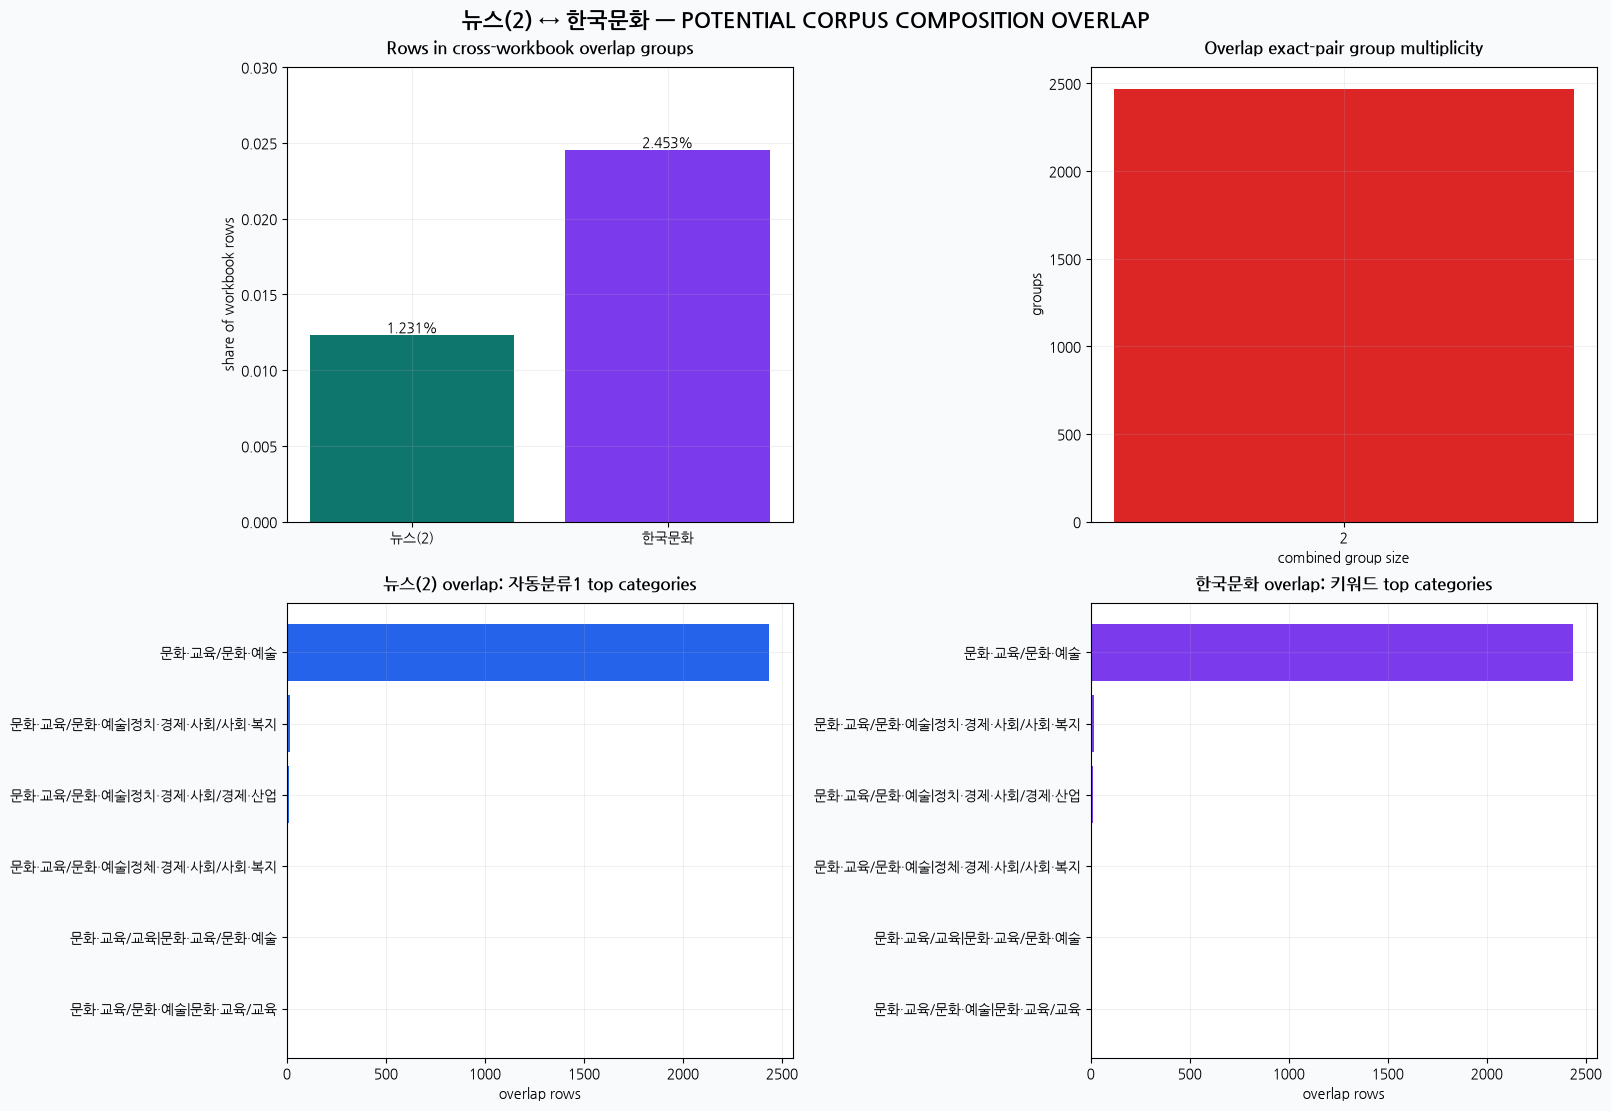

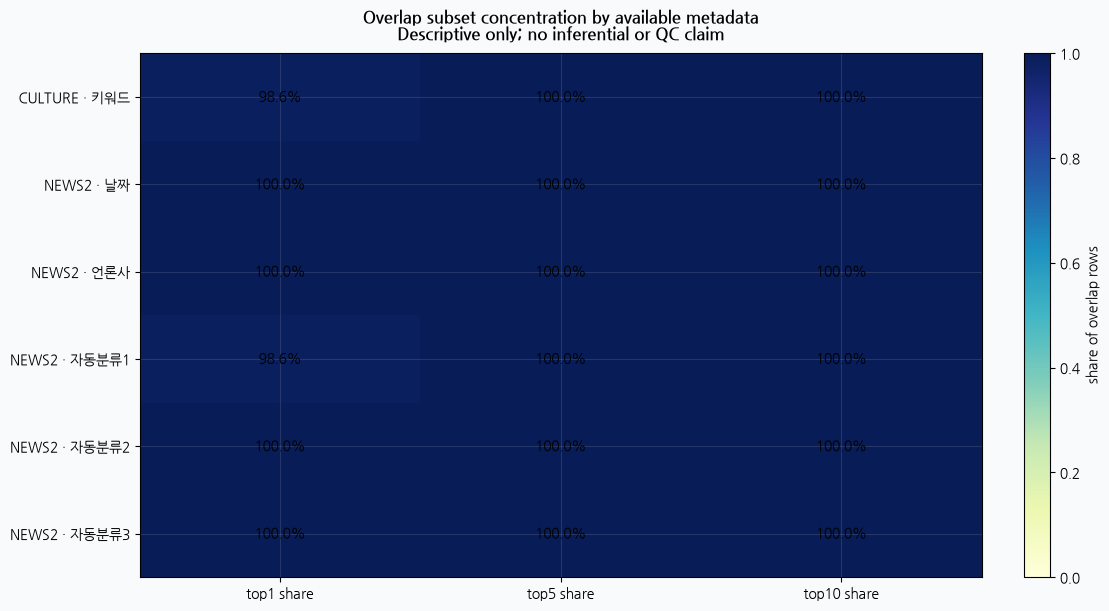

PosixPath('/home/sieg/projects-wsl/Tokenization_Premium/.agent_worktrees/raw-eda/outputs/figures/eda_raw/targeted_decision_audit/legacy_news2_culture_overlap_concentration.png')

In [9]:

display(Markdown("### 9.1 뉴스(2) ↔ 한국문화 exact raw KO/EN overlap"))
display(overlap_summary_legacy_df)
display(Markdown("### 9.2 Overlap duplicate-group multiplicity"))
display(overlap_multiplicity_legacy_df)
display(Markdown("### 9.3 Available metadata distributions within overlap rows"))
for (corpus,field),part in overlap_metadata_legacy_df.groupby(["corpus","metadata_field"]):
    display(Markdown(f"#### {corpus} · {field}")); display(part.head(20))
display(Markdown("### 9.4 Descriptive subset concentration"))
display(overlap_concentration_legacy_df)
display(Markdown("이 appendix는 exact raw pair의 구성 중첩만 관찰한다. 오류·오염·제외·provenance 동일성을 판정하지 않으며 상태는 **POTENTIAL CORPUS COMPOSITION OVERLAP**이다."))

configure_plotting()
fig,axes=plt.subplots(2,2,figsize=(16,11),constrained_layout=True)
summary=overlap_summary_legacy_df.iloc[0]
axes[0,0].bar(["뉴스(2)","한국문화"],[summary.news2_overlap_row_rate,summary.culture_overlap_row_rate],color=["#0F766E","#7C3AED"])
axes[0,0].set_title("Rows in cross-workbook overlap groups"); axes[0,0].set_ylabel("share of workbook rows"); axes[0,0].set_ylim(0,max(.03,summary.culture_overlap_row_rate*1.2))
for i,value in enumerate([summary.news2_overlap_row_rate,summary.culture_overlap_row_rate]): axes[0,0].text(i,value,f"{value:.3%}",ha="center",va="bottom")

mult=overlap_multiplicity_legacy_df.groupby("combined_group_multiplicity",as_index=False).exact_pair_group_count.sum()
axes[0,1].bar(mult.combined_group_multiplicity.astype(str),mult.exact_pair_group_count,color="#DC2626")
axes[0,1].set_title("Overlap exact-pair group multiplicity"); axes[0,1].set_xlabel("combined group size"); axes[0,1].set_ylabel("groups")

news_top=overlap_metadata_legacy_df[(overlap_metadata_legacy_df.corpus=="NEWS2") & (overlap_metadata_legacy_df.metadata_field=="자동분류1")].head(12).sort_values("overlap_row_count")
axes[1,0].barh(news_top.category.astype(str).str.slice(0,36),news_top.overlap_row_count,color="#2563EB")
axes[1,0].set_title("뉴스(2) overlap: 자동분류1 top categories"); axes[1,0].set_xlabel("overlap rows")

culture_top=overlap_metadata_legacy_df[(overlap_metadata_legacy_df.corpus=="CULTURE") & (overlap_metadata_legacy_df.metadata_field=="키워드")].head(12).sort_values("overlap_row_count")
axes[1,1].barh(culture_top.category.astype(str).str.slice(0,36),culture_top.overlap_row_count,color="#7C3AED")
axes[1,1].set_title("한국문화 overlap: 키워드 top categories"); axes[1,1].set_xlabel("overlap rows")
fig.suptitle("뉴스(2) ↔ 한국문화 — POTENTIAL CORPUS COMPOSITION OVERLAP",fontsize=16,fontweight="bold")
save_target_figure(fig,"legacy_news2_culture_overlap_composition.png")

concentration=overlap_concentration_legacy_df.set_index(["corpus","metadata_field"])[["top1_share","top5_share","top10_share"]]
fig,ax=plt.subplots(figsize=(11,6),constrained_layout=True)
image=ax.imshow(concentration.values,aspect="auto",cmap="YlGnBu",vmin=0,vmax=1)
ax.set_xticks(range(3),["top1 share","top5 share","top10 share"])
ax.set_yticks(range(len(concentration)),[" · ".join(idx) for idx in concentration.index])
for i in range(len(concentration)):
    for j in range(3): ax.text(j,i,f"{concentration.iloc[i,j]:.1%}",ha="center",va="center")
ax.set_title("Overlap subset concentration by available metadata\nDescriptive only; no inferential or QC claim")
fig.colorbar(image,ax=ax,label="share of overlap rows")
save_target_figure(fig,"legacy_news2_culture_overlap_concentration.png")
